# Accesibilidad al campus y permanencia estudiantil
### Análisis exploratorio: tiempo de viaje, transbordos y abandono universitario

Este notebook analiza si la **accesibilidad geográfica** (tiempo de viaje, distancia y transbordos
en transporte público) está asociada con el **abandono estudiantil** y la **pérdida de créditos**.

Estructura del análisis:
1. Configuración y estilo visual
2. Carga y preparación de datos
3. Curvas de supervivencia (Kaplan-Meier): permanencia según accesibilidad
4. Distribución del tiempo de viaje según estado del estudiante
5. Relación entre tiempo de viaje y pérdida de créditos


> ⚠️ **Requisito previo:** este notebook debe ejecutarse *después* de `rutas_distancias_tiempo.ipynb`, ya que lee su salida (`outputs/estudiantes_con_rutas.xlsx`).


## 1. Configuración y estilo visual

Se define una paleta de colores única y una configuración de `matplotlib` que se reutiliza en
**todo el notebook**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import PercentFormatter

# Si no tienes lifelines instalado, descomenta la siguiente línea:
# %pip install lifelines

from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test


### Configuración de rutas (relativas al repositorio)

Este notebook vive en `src/`, junto a `rutas_distancias_tiempo.ipynb`. Lee su insumo
directamente desde `outputs/estudiantes_con_rutas.xlsx` (la salida de ese notebook) y
guarda todas las figuras en `figures/`. No requiere editar ninguna ruta a mano.


In [2]:
from pathlib import Path

# Carpeta donde vive este notebook (src/). Si se ejecuta en un entorno donde
# `__file__` no existe (Jupyter clásico), se usa cwd() como respaldo.
try:
    NOTEBOOK_DIR = Path(__file__).resolve().parent
except NameError:
    NOTEBOOK_DIR = Path.cwd().resolve()

# La raíz del repo es la carpeta padre de src/.
BASE_DIR = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "src" else NOTEBOOK_DIR

DATA_DIR = BASE_DIR / "data" / "raw"
OUTPUTS_DIR = BASE_DIR / "outputs"
FIGURES_DIR = BASE_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

RUTA_ENTRADA = OUTPUTS_DIR / "estudiantes_con_rutas.xlsx"

print(f"📁 Repositorio detectado en: {BASE_DIR}")
print(f"📄 Insumo esperado en:       {RUTA_ENTRADA}")
print(f"🖼️  Figuras se guardarán en:  {FIGURES_DIR}")


📁 Repositorio detectado en: C:\Users\Max\Documents\Atenea\Data Jam
📄 Insumo esperado en:       C:\Users\Max\Documents\Atenea\Data Jam\outputs\estudiantes_con_rutas.xlsx
🖼️  Figuras se guardarán en:  C:\Users\Max\Documents\Atenea\Data Jam\figures


In [3]:
# ----------------------------------------------------------------
# PALETA DE COLORES (consistente en todo el notebook)
# ----------------------------------------------------------------
PALETA = {
    "azul_oscuro": "#0C2340",   # títulos, líneas de énfasis
    "azul":        "#1F4E79",   # texto secundario oscuro
    "azul_medio":  "#2E75B6",   # categoría 1 (p. ej. "Alta accesibilidad" / "Activo")
    "azul_claro":  "#9DC3E6",   # apoyo / bandas de confianza
    "gris_oscuro": "#404040",   # texto de ejes
    "gris":        "#7F7F7F",   # texto secundario / anotaciones
    "gris_claro":  "#D9D9D9",   # grillas, bordes
    "acento":      "#D96C06",   # categoría 2 (p. ej. "Baja accesibilidad" / "Abandona") — único color cálido
    "fondo":       "#FFFFFF",
}

COLOR_GRUPO = {
    "Alta accesibilidad": PALETA["azul_medio"],
    "Baja accesibilidad": PALETA["acento"],
}
COLOR_ESTADO = {
    "Activo":   PALETA["azul_medio"],
    "Abandona": PALETA["acento"],
}

mpl.rcParams.update({
    "figure.facecolor": PALETA["fondo"],
    "axes.facecolor": PALETA["fondo"],
    "savefig.facecolor": PALETA["fondo"],
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 11,
    "axes.edgecolor": PALETA["gris_claro"],
    "axes.linewidth": 0.8,
    "axes.grid": True,
    "grid.color": PALETA["gris_claro"],
    "grid.linewidth": 0.6,
    "grid.alpha": 0.6,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.titlecolor": PALETA["azul_oscuro"],
    "axes.labelsize": 11,
    "axes.labelcolor": PALETA["gris_oscuro"],
    "xtick.color": PALETA["gris_oscuro"],
    "ytick.color": PALETA["gris_oscuro"],
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.frameon": False,
    "legend.fontsize": 10,
    "figure.dpi": 110,
    "savefig.dpi": 220,
})


def estilo_titulo(ax, titulo, subtitulo=None):
    """Título alineado a la izquierda + subtítulo gris, estilo consultoría."""
    ax.set_title(titulo, loc="left", pad=26 if subtitulo else 12)
    if subtitulo:
        ax.text(0, 1.035, subtitulo, transform=ax.transAxes,
                 fontsize=10, color=PALETA["gris"], ha="left", va="bottom")


def fuente_nota(fig, texto):
    """Nota de fuente/metodología al pie del gráfico."""
    fig.text(0.01, -0.02, texto, fontsize=8.5, color=PALETA["gris"], ha="left")


## 2. Carga y preparación de datos

Ajusta el diccionario `COLS` si los nombres de columna en tu archivo son distintos —
todo el resto del notebook referencia las columnas a través de este diccionario, así que
solo necesitas editar esta celda.

In [4]:
estudiantes_final = pd.read_excel(RUTA_ENTRADA, "Sheet1")

# ----------------------------------------------------------------
# Puente de nombres: rutas_distancias_tiempo.ipynb genera columnas con
# prefijo "conn_" (conn_dist_total_estimada_km, conn_tiempo_total_min,
# conn_transbordos). Este notebook trabaja con nombres "TOTAL_*", así que
# las renombramos aquí para poder correr el pipeline de punta a punta sin
# editar el Excel a mano.
# Si ya renombraste estas columnas manualmente, esta celda simplemente no
# encuentra nada que renombrar y sigue de largo.
# ----------------------------------------------------------------
RENOMBRES_RUTEO = {
    "conn_dist_total_estimada_km": "TOTAL_KM",
    "conn_tiempo_total_min": "TOTAL_TIEMPO",
    "conn_transbordos": "TOTAL_TRANSBORDOS",
}
columnas_a_renombrar = {k: v for k, v in RENOMBRES_RUTEO.items() if k in estudiantes_final.columns}
if columnas_a_renombrar:
    estudiantes_final = estudiantes_final.rename(columns=columnas_a_renombrar)
    print(f"🔗 Columnas de ruteo renombradas: {columnas_a_renombrar}")

# ----------------------------------------------------------------
# Mapeo de columnas: ajusta los valores si tus nombres reales difieren
# ----------------------------------------------------------------
COLS = dict(
    abandona          = "ABANDONA",          # 1 = abandona, 0 = sigue activo
    sexo              = "SEXO",              # 1 = hombre, 0 = mujer
    sisben            = "TIENE_SISBEN",      # 1 = tiene SISBEN, 0 = no
    creditos_totales  = "TOTAL_CREDITOS",    # créditos totales del programa
    periodos_totales  = "TOTAL_PERIODOS",    # periodos totales del programa
    creditos_aprob    = "CREDITOS_APROB",    # % créditos aprobados a la 7ma matrícula
    creditos_perd     = "CREDITOS_PERD",     # % créditos perdidos a la 7ma matrícula
    km                = "TOTAL_KM",          # km recorridos casa -> universidad
    tiempo            = "TOTAL_TIEMPO",      # minutos de viaje casa -> universidad
    transbordos       = "TOTAL_TRANSBORDOS", # número de transbordos en transporte público
)

# Verificación temprana: si falta alguna columna esperada, mejor fallar aquí
# con un mensaje claro que más adelante con un KeyError críptico.
faltantes = [nombre for nombre in COLS.values() if nombre not in estudiantes_final.columns]
if faltantes:
    raise KeyError(
        f"Faltan columnas esperadas en '{RUTA_ENTRADA.name}': {faltantes}. "
        "Revisa el diccionario COLS de esta celda y ajusta los nombres a los "
        "de tu archivo."
    )

df = estudiantes_final.copy()

# Variables derivadas
df["estado"] = np.where(df[COLS["abandona"]] == 1, "Deja la U", "Sigue en la U")

mediana_tiempo = df[COLS["tiempo"]].median()
df["grupo_accesibilidad"] = np.where(
    df[COLS["tiempo"]] <= mediana_tiempo, "Alta accesibilidad", "Baja accesibilidad"
)

print(f"Estudiantes totales: {len(df):,}")
print(f"Mediana tiempo de viaje: {mediana_tiempo:.1f} min (punto de corte de accesibilidad)")
print()
print(df["grupo_accesibilidad"].value_counts())
print()
print(df["estado"].value_counts(normalize=True).mul(100).round(1).astype(str) + "%")


🔗 Columnas de ruteo renombradas: {'conn_dist_total_estimada_km': 'TOTAL_KM', 'conn_tiempo_total_min': 'TOTAL_TIEMPO', 'conn_transbordos': 'TOTAL_TRANSBORDOS'}
Estudiantes totales: 2,357
Mediana tiempo de viaje: 51.6 min (punto de corte de accesibilidad)

grupo_accesibilidad
Alta accesibilidad    1183
Baja accesibilidad    1174
Name: count, dtype: int64

estado
Sigue en la U    73.3%
Deja la U        26.7%
Name: proportion, dtype: object


## 3. Curvas de supervivencia (Kaplan-Meier)

**Pregunta:** ¿La probabilidad de "sobrevivir" (permanecer matriculado) a medida que avanza el
programa es distinta entre estudiantes con alta y baja accesibilidad al campus?

Se usa el **% de créditos aprobados** como proxy del avance académico ("tiempo") y `ABANDONA`
como evento. Se compara el grupo de **alta accesibilidad** (tiempo de viaje ≤ mediana) contra
**baja accesibilidad** (> mediana), y se valida la diferencia con una prueba log-rank.

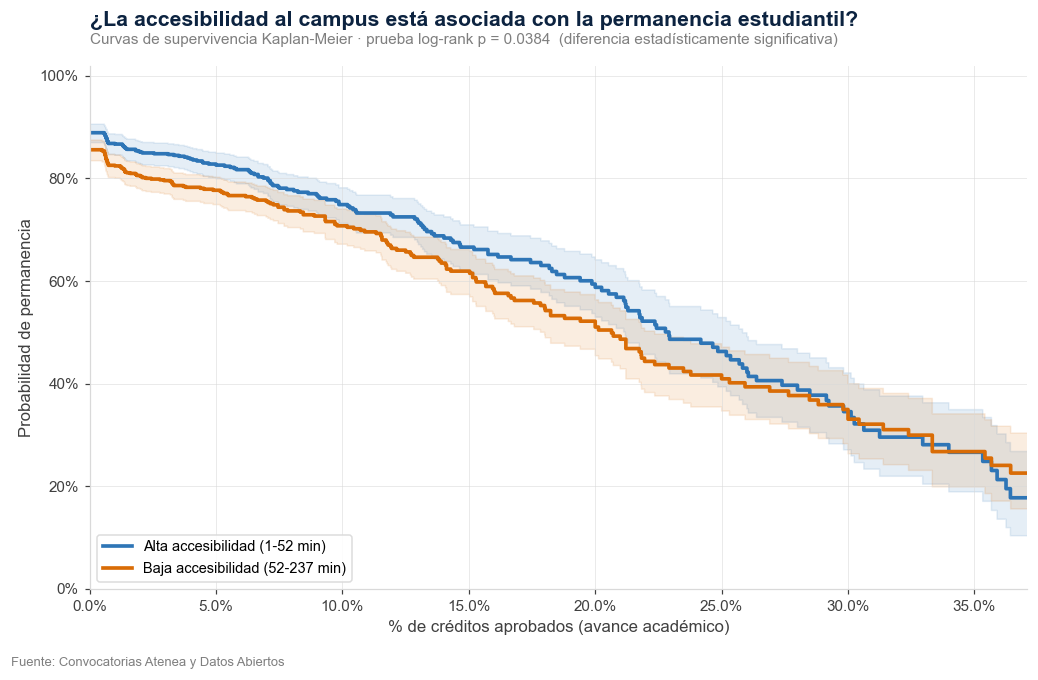

In [5]:
fig, ax = plt.subplots(figsize=(9.5, 6))

serie_avance = df[COLS["creditos_aprob"]]
es_fraccion = serie_avance.max() <= 1.5
df["_avance_pct"] = serie_avance * (100 if es_fraccion else 1)

rango_minutos = df.groupby("grupo_accesibilidad")[COLS["tiempo"]].agg(["min", "max"])

UMBRAL_EN_RIESGO = 15
limite_x = df["_avance_pct"].max()
for grupo in COLOR_GRUPO:
    sub = df[df["grupo_accesibilidad"] == grupo]
    kmf_tmp = KaplanMeierFitter().fit(sub["_avance_pct"], sub[COLS["abandona"]])
    en_riesgo = kmf_tmp.event_table["at_risk"]
    validos = en_riesgo[en_riesgo >= UMBRAL_EN_RIESGO].index
    if len(validos):
        limite_x = min(limite_x, validos.max())

resultados_km = {}
for grupo, color in COLOR_GRUPO.items():
    sub = df[df["grupo_accesibilidad"] == grupo]
    min_g, max_g = rango_minutos.loc[grupo, "min"], rango_minutos.loc[grupo, "max"]
    etiqueta_leyenda = f"{grupo} ({min_g:.0f}-{max_g:.0f} min)"

    kmf = KaplanMeierFitter()
    kmf.fit(durations=sub["_avance_pct"], event_observed=sub[COLS["abandona"]], label=etiqueta_leyenda)
    resultados_km[grupo] = kmf
    kmf.plot_survival_function(ax=ax, color=color, ci_show=True, ci_alpha=0.12,
                                linewidth=2.4, show_censors=False)

grupo_a = df[df["grupo_accesibilidad"] == "Alta accesibilidad"]
grupo_b = df[df["grupo_accesibilidad"] == "Baja accesibilidad"]
test_km = logrank_test(
    grupo_a["_avance_pct"], grupo_b["_avance_pct"],
    event_observed_A=grupo_a[COLS["abandona"]], event_observed_B=grupo_b[COLS["abandona"]],
)

ax.set_xlim(0, limite_x * 1.05)
ax.set_ylim(0, 1.02)
ax.set_xlabel("% de créditos aprobados (avance académico)")
ax.set_ylabel("Probabilidad de permanencia")
ax.xaxis.set_major_formatter(PercentFormatter(100))
ax.yaxis.set_major_formatter(PercentFormatter(1.0))

# --- Leyenda de caja normal, abajo a la izquierda (zona sin datos) ---
ax.legend(loc="lower left", fontsize=9.5, frameon=True, facecolor="white",
          edgecolor=PALETA["gris_claro"], framealpha=0.9)

estilo_titulo(
    ax,
    "¿La accesibilidad al campus está asociada con la permanencia estudiantil?",
    f"Curvas de supervivencia Kaplan-Meier · prueba log-rank p = {test_km.p_value:.4f}"
    + ("  (diferencia estadísticamente significativa)" if test_km.p_value < 0.05 else "  (diferencia no significativa al 5%)")
)
fuente_nota(fig, "Fuente: Convocatorias Atenea y Datos Abiertos")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "1.kaplan_meier_accesibilidad.png", bbox_inches="tight")
plt.show()

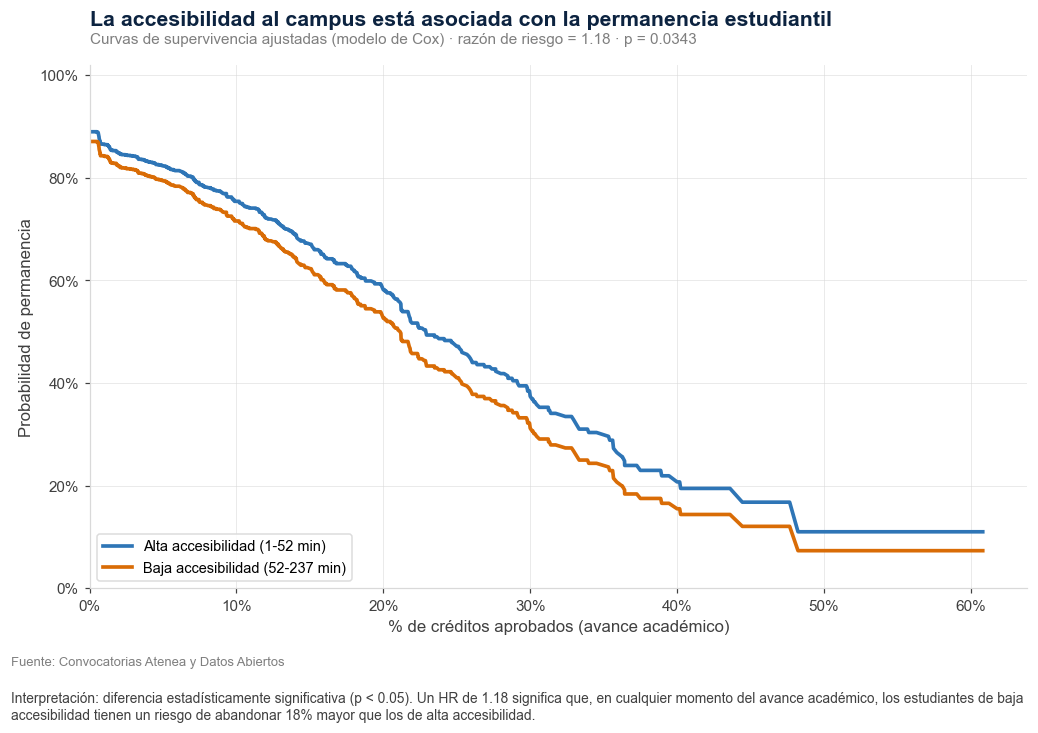

In [6]:
from lifelines import CoxPHFitter

df["_baja_accesibilidad"] = (df["grupo_accesibilidad"] == "Baja accesibilidad").astype(int)
rango_minutos = df.groupby("grupo_accesibilidad")[COLS["tiempo"]].agg(["min", "max"])

cph = CoxPHFitter()
cph.fit(
    df[["_avance_pct", COLS["abandona"], "_baja_accesibilidad"]],
    duration_col="_avance_pct", event_col=COLS["abandona"],
)

fig, ax = plt.subplots(figsize=(9.5, 6))
for grupo, color in COLOR_GRUPO.items():
    valor_covariable = 1 if grupo == "Baja accesibilidad" else 0
    min_g, max_g = rango_minutos.loc[grupo, "min"], rango_minutos.loc[grupo, "max"]
    etiqueta_leyenda = f"{grupo} ({min_g:.0f}-{max_g:.0f} min)"

    sf = cph.predict_survival_function(pd.DataFrame({"_baja_accesibilidad": [valor_covariable]}))
    ax.plot(sf.index, sf.iloc[:, 0], color=color, linewidth=2.4, label=etiqueta_leyenda)

hr = cph.summary.loc["_baja_accesibilidad", "exp(coef)"]
p_cox = cph.summary.loc["_baja_accesibilidad", "p"]

ax.set_xlim(0, df["_avance_pct"].max() * 1.05)
ax.set_ylim(0, 1.02)
ax.set_xlabel("% de créditos aprobados (avance académico)")
ax.set_ylabel("Probabilidad de permanencia")
ax.xaxis.set_major_formatter(PercentFormatter(100))
ax.yaxis.set_major_formatter(PercentFormatter(1.0))

ax.legend(loc="lower left", fontsize=9.5, frameon=True, facecolor="white",
          edgecolor=PALETA["gris_claro"], framealpha=0.9)

estilo_titulo(
    ax,
    "La accesibilidad al campus está asociada con la permanencia estudiantil",
    f"Curvas de supervivencia ajustadas (modelo de Cox) · razón de riesgo = {hr:.2f} · p = {p_cox:.4f}"
)

# --- NUEVO: interpretación en texto plano, justo antes de la fuente ---
es_significativo = p_cox < 0.05
direccion = "mayor" if hr > 1 else "menor"
magnitud_pct = abs(hr - 1) * 100

texto_significancia = "diferencia estadísticamente significativa (p < 0.05)" if es_significativo \
    else f"diferencia NO significativa al 5% (p = {p_cox:.3f})"

texto_interpretacion = (
    f"Interpretación: {texto_significancia}. Un HR de {hr:.2f} significa que, en cualquier momento del avance "
    f"académico, los estudiantes de baja accesibilidad tienen un riesgo de abandonar {magnitud_pct:.0f}% "
    f"{direccion} que los de alta accesibilidad."
)
if not es_significativo:
    texto_interpretacion += " Con este p-valor, no se puede afirmar con confianza que la diferencia sea real y no producto del azar."

fig.text(0.01, -0.06, texto_interpretacion, fontsize=9, color=PALETA["gris_oscuro"],
          ha="left", va="top", wrap=True)

fuente_nota(fig, "Fuente: Convocatorias Atenea y Datos Abiertos")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "2.kaplan_meier_accesibilidad_cox.png", bbox_inches="tight")
plt.show()

## 4. Tiempo de viaje según estado del estudiante

**Pregunta:** ¿Los estudiantes que abandonan tienen, en general, tiempos de viaje más largos
que quienes permanecen activos?

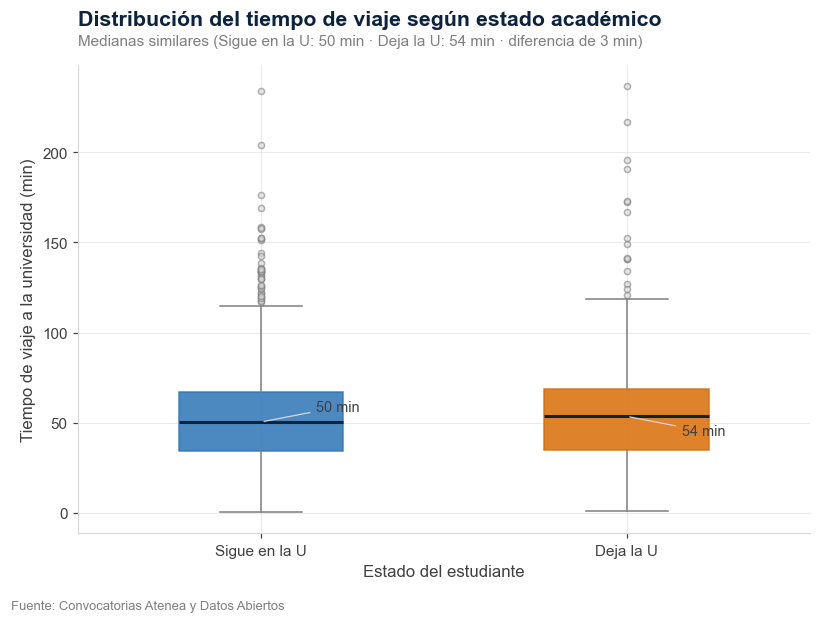

In [7]:

COLOR_ESTADO = {"Sigue en la U": PALETA["azul_medio"], "Deja la U": PALETA["acento"]}

fig, ax = plt.subplots(figsize=(7.5, 5.5))

orden_estado = ["Sigue en la U", "Deja la U"]
datos_box = [df.loc[df["estado"] == e, COLS["tiempo"]] for e in orden_estado]

bp = ax.boxplot(
    datos_box, tick_labels=orden_estado, patch_artist=True, widths=0.45,
    medianprops=dict(color=PALETA["azul_oscuro"], linewidth=2),
    whiskerprops=dict(color=PALETA["gris"]),
    capprops=dict(color=PALETA["gris"]),
    flierprops=dict(marker="o", markersize=4, markerfacecolor=PALETA["gris_claro"],
                     markeredgecolor=PALETA["gris"], alpha=0.6),
)
for patch, estado in zip(bp["boxes"], orden_estado):
    patch.set_facecolor(COLOR_ESTADO[estado])
    patch.set_alpha(0.85)
    patch.set_edgecolor(COLOR_ESTADO[estado])

# Medianas como referencia numérica, separando las etiquetas si quedan muy cerca en altura
medianas = {estado: df.loc[df["estado"] == estado, COLS["tiempo"]].median() for estado in orden_estado}
rango_y = df[COLS["tiempo"]].max() - df[COLS["tiempo"]].min()
cerca = abs(medianas["Sigue en la U"] - medianas["Deja la U"]) < (rango_y * 0.04)

for i, estado in enumerate(orden_estado, start=1):
    mediana = medianas[estado]
    # si están cerca, la primera sube y la segunda baja, para no solaparse
    y_etiqueta = mediana + (rango_y * 0.035 if i == 1 else -rango_y * 0.035) if cerca else mediana
    ax.annotate(f"{mediana:.0f} min", xy=(i, mediana), xytext=(i + 0.15, y_etiqueta),
                fontsize=9.5, color=PALETA["gris_oscuro"], va="center",
                arrowprops=dict(arrowstyle="-", color=PALETA["gris_claro"], lw=0.8) if cerca else None)

ax.set_ylabel("Tiempo de viaje a la universidad (min)")
ax.set_xlabel("Estado del estudiante")

diferencia = medianas["Deja la U"] - medianas["Sigue en la U"]
estilo_titulo(
    ax,
    "Distribución del tiempo de viaje según estado académico",
    f"Medianas similares (Sigue en la U: {medianas['Sigue en la U']:.0f} min · "
    f"Deja la U: {medianas['Deja la U']:.0f} min · diferencia de {abs(diferencia):.0f} min)"
)
fuente_nota(fig, "Fuente: Convocatorias Atenea y Datos Abiertos")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "3.boxplot_tiempo_viaje_estado.png", bbox_inches="tight")
plt.show()

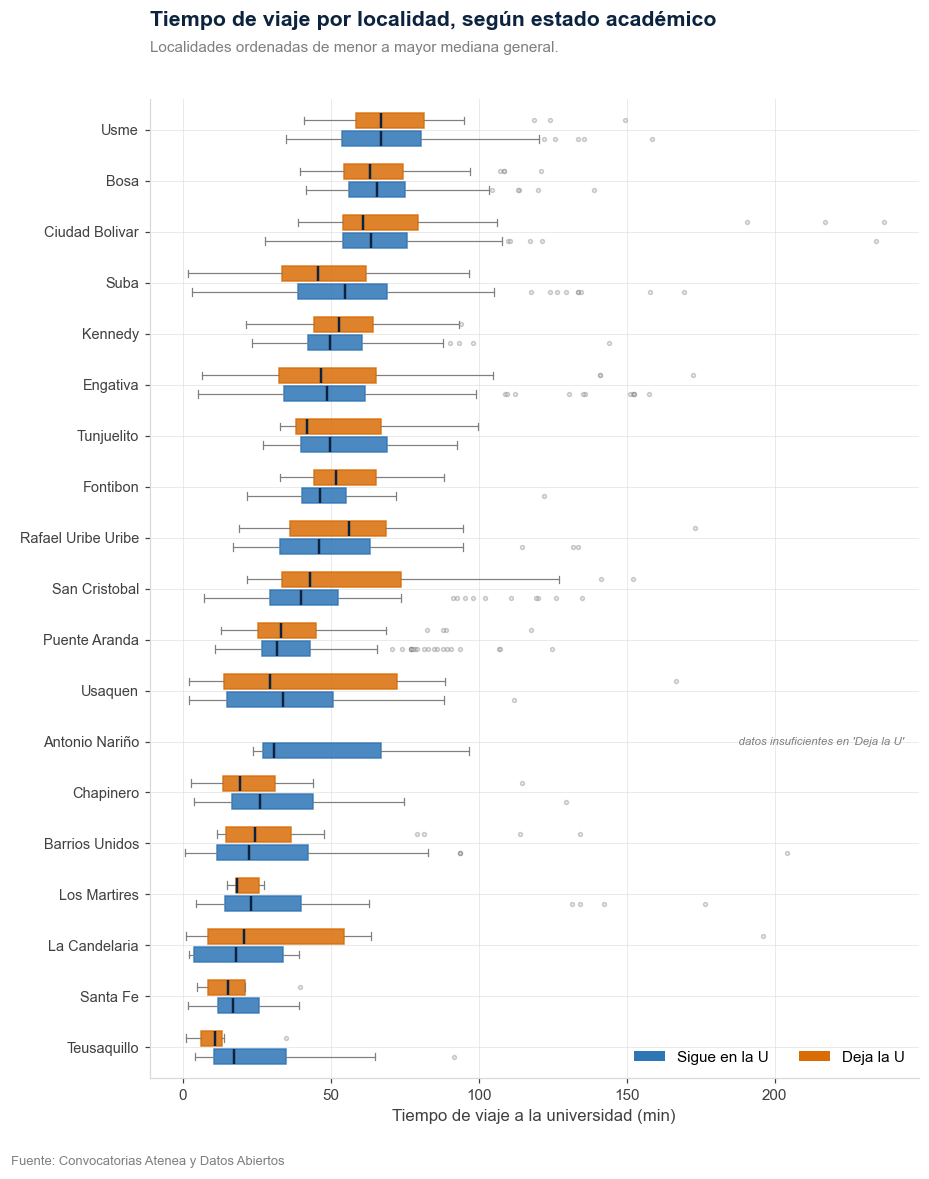

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# --- Estilo (ya definido antes en el notebook, se incluye aquí por si acaso) ---
def estilo_titulo(ax, t, s=None):
    ax.set_title(t, loc="left", pad=48 if s else 12)
    if s:
        ax.text(0, 1.045, s, transform=ax.transAxes, fontsize=10, color=PALETA["gris"], ha="left", va="bottom")

def fuente_nota(fig, texto):
    fig.text(0.01, -0.02, texto, fontsize=8.5, color=PALETA["gris"], ha="left")

# --- Boxplot de tiempo de viaje por localidad, diferenciado por estado ---
orden_localidades = (
    df.groupby("LOCALIDAD")[COLS["tiempo"]].median().sort_values().index.tolist()
)
orden_estado = ["Sigue en la U", "Deja la U"]   # FIX: nombres nuevos, no "Activo"/"Abandona"
n_min = 5

fig, ax = plt.subplots(figsize=(8.5, max(6, 0.55 * len(orden_localidades))))

offset = 0.18
grupos_insuficientes = []
for estado in orden_estado:
    posiciones, datos_box = [], []
    for i, loc in enumerate(orden_localidades):
        sub = df.loc[(df["LOCALIDAD"] == loc) & (df["estado"] == estado), COLS["tiempo"]]
        if len(sub) >= n_min:
            posiciones.append(i + (offset if estado == "Deja la U" else -offset))  # FIX: "Deja la U"
            datos_box.append(sub)
        else:
            grupos_insuficientes.append(i)
    bp = ax.boxplot(
        datos_box, positions=posiciones, widths=0.3, vert=False, patch_artist=True,
        medianprops=dict(color=PALETA["azul_oscuro"], linewidth=1.6),
        whiskerprops=dict(color=PALETA["gris"], linewidth=0.8),
        capprops=dict(color=PALETA["gris"], linewidth=0.8),
        flierprops=dict(marker="o", markersize=2.5, markerfacecolor=PALETA["gris_claro"],
                         markeredgecolor=PALETA["gris"], alpha=0.4),
    )
    for patch in bp["boxes"]:
        patch.set_facecolor(COLOR_ESTADO[estado])
        patch.set_alpha(0.85)
        patch.set_edgecolor(COLOR_ESTADO[estado])

etiquetas_localidad = [loc.title() for loc in orden_localidades]
ax.set_yticks(range(len(orden_localidades)))
ax.set_yticklabels(etiquetas_localidad, fontsize=9.5)
ax.set_ylim(-0.6, len(orden_localidades) - 0.4)
ax.set_xlabel("Tiempo de viaje a la universidad (min)")
ax.set_ylabel("")

for i in set(grupos_insuficientes):
    ax.text(ax.get_xlim()[1] * 0.98, i, "  datos insuficientes en 'Deja la U'",  # FIX: texto actualizado
             fontsize=7.5, color=PALETA["gris"], ha="right", va="center", style="italic")

ax.legend(handles=[Patch(facecolor=COLOR_ESTADO[e], label=e) for e in orden_estado],
          loc="lower right", ncol=2)

estilo_titulo(
    ax,
    "Tiempo de viaje por localidad, según estado académico",
    f"Localidades ordenadas de menor a mayor mediana general."
)

fuente_nota(fig, "Fuente: Convocatorias Atenea y Datos Abiertos")  # estaba faltando esta línea también

plt.tight_layout()
plt.savefig(FIGURES_DIR / "4.boxplot_tiempo_localidad_estado.png", bbox_inches="tight")
plt.show()

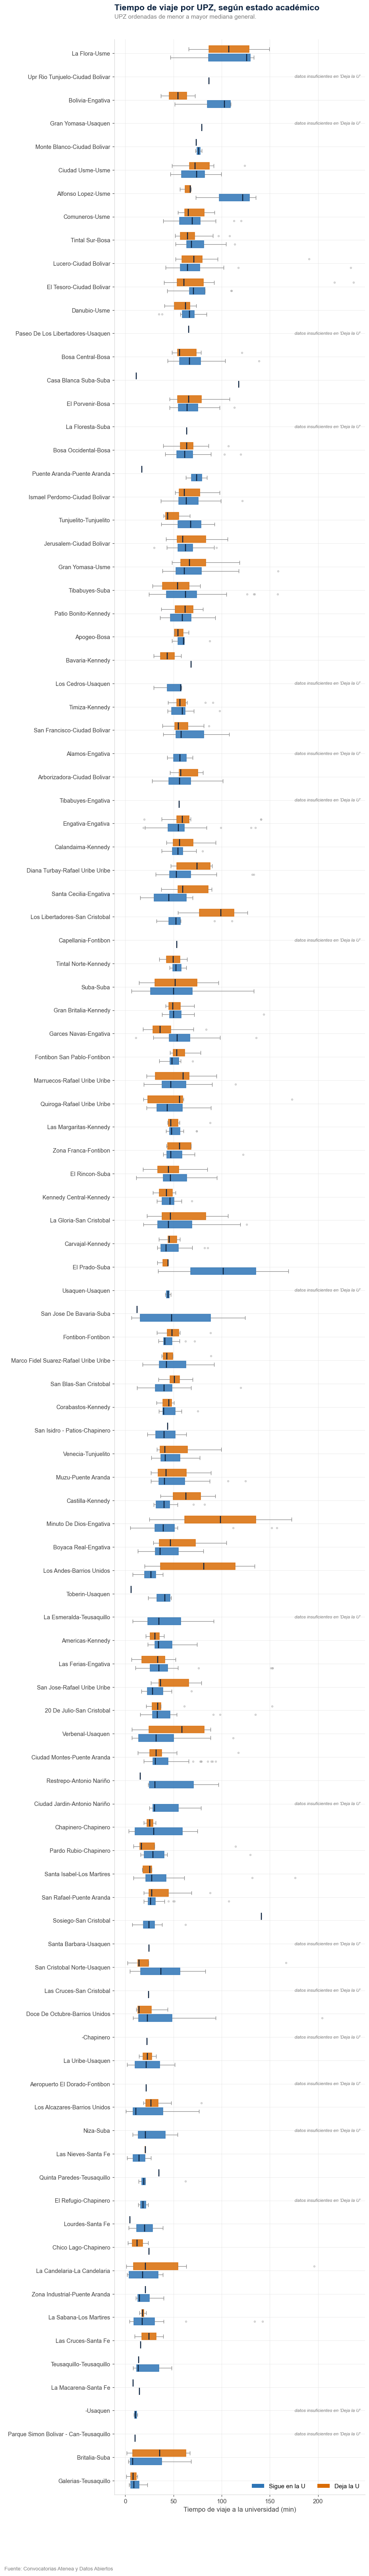

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def estilo_titulo(ax, t, s=None):
    ax.set_title(t, loc="left", pad=48 if s else 12)
    if s:
        ax.text(0, 1.008, s, transform=ax.transAxes, fontsize=10, color=PALETA["gris"], ha="left", va="bottom")

def fuente_nota(fig, texto):
    fig.text(0.01, -0.02, texto, fontsize=8.5, color=PALETA["gris"], ha="left")

orden_localidades = (
    df.groupby("UPZ")[COLS["tiempo"]].median().sort_values().index.tolist()
)
orden_estado = ["Sigue en la U", "Deja la U"]   # FIX: nombres nuevos
n_min = 1

fig, ax = plt.subplots(figsize=(8.5, max(6, 0.55 * len(orden_localidades))))

offset = 0.18
grupos_insuficientes = []
for estado in orden_estado:
    posiciones, datos_box = [], []
    for i, loc in enumerate(orden_localidades):
        sub = df.loc[(df["UPZ"] == loc) & (df["estado"] == estado), COLS["tiempo"]]
        if len(sub) >= n_min:
            posiciones.append(i + (offset if estado == "Deja la U" else -offset))  # FIX
            datos_box.append(sub)
        else:
            grupos_insuficientes.append(i)
    bp = ax.boxplot(
        datos_box, positions=posiciones, widths=0.3, vert=False, patch_artist=True,
        medianprops=dict(color=PALETA["azul_oscuro"], linewidth=1.6),
        whiskerprops=dict(color=PALETA["gris"], linewidth=0.8),
        capprops=dict(color=PALETA["gris"], linewidth=0.8),
        flierprops=dict(marker="o", markersize=2.5, markerfacecolor=PALETA["gris_claro"],
                         markeredgecolor=PALETA["gris"], alpha=0.4),
    )
    for patch in bp["boxes"]:
        patch.set_facecolor(COLOR_ESTADO[estado])
        patch.set_alpha(0.85)
        patch.set_edgecolor(COLOR_ESTADO[estado])

etiquetas_localidad = [loc.title() for loc in orden_localidades]
ax.set_yticks(range(len(orden_localidades)))
ax.set_yticklabels(etiquetas_localidad, fontsize=9.5)
ax.set_ylim(-0.6, len(orden_localidades) - 0.4)
ax.set_xlabel("Tiempo de viaje a la universidad (min)")
ax.set_ylabel("")

for i in set(grupos_insuficientes):
    ax.text(ax.get_xlim()[1] * 0.98, i, "  datos insuficientes en 'Deja la U'",
             fontsize=7.5, color=PALETA["gris"], ha="right", va="center", style="italic")

ax.legend(handles=[Patch(facecolor=COLOR_ESTADO[e], label=e) for e in orden_estado],
          loc="lower right", ncol=2)

estilo_titulo(
    ax,
    "Tiempo de viaje por UPZ, según estado académico",
    f"UPZ ordenadas de menor a mayor mediana general."
)
fuente_nota(fig, "Fuente: Convocatorias Atenea y Datos Abiertos")

# FIX: tight_layout ANTES de savefig, no después
plt.tight_layout()
plt.savefig(FIGURES_DIR / "5.boxplot_tiempo_upz_estado.png", bbox_inches="tight")
plt.show()

## 5. Tiempo de viaje vs. aprobación de créditos

**Pregunta:** ¿Existe una relación entre el tiempo de viaje y el porcentaje de créditos
aprobados? Se colorea por grupo de accesibilidad y se añade una línea de tendencia general.

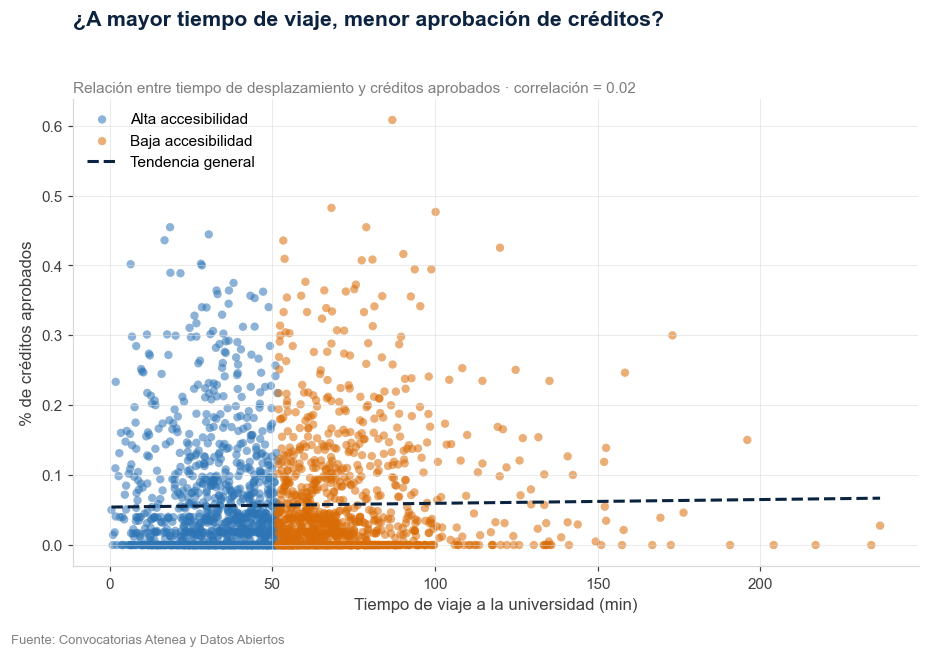

In [10]:
fig, ax = plt.subplots(figsize=(8.5, 5.8))

for grupo, color in COLOR_GRUPO.items():
    sub = df[df["grupo_accesibilidad"] == grupo]
    ax.scatter(
        sub[COLS["tiempo"]], sub[COLS["creditos_aprob"]],
        s=30, alpha=0.55, color=color, edgecolors="none", label=grupo,
    )

# Línea de tendencia (regresión lineal simple) sobre el total de datos
coef = np.polyfit(df[COLS["tiempo"]], df[COLS["creditos_aprob"]], 1)
xs = np.linspace(df[COLS["tiempo"]].min(), df[COLS["tiempo"]].max(), 100)
ax.plot(xs, np.polyval(coef, xs), color=PALETA["azul_oscuro"], linewidth=2,
        linestyle="--", label="Tendencia general")

correlacion = df[[COLS["tiempo"], COLS["creditos_aprob"]]].corr().iloc[0, 1]

ax.set_xlabel("Tiempo de viaje a la universidad (min)")
ax.set_ylabel("% de créditos aprobados")
ax.legend(loc="upper left")

estilo_titulo(
    ax,
    "¿A mayor tiempo de viaje, menor aprobación de créditos?",
    f"Relación entre tiempo de desplazamiento y créditos aprobados · correlación = {correlacion:.2f}"
)


fuente_nota(fig, "Fuente: Convocatorias Atenea y Datos Abiertos")


plt.tight_layout()
plt.savefig(FIGURES_DIR / "6.scatterplot_aprobacion_creditos_tiempo.png", bbox_inches="tight")
plt.show()

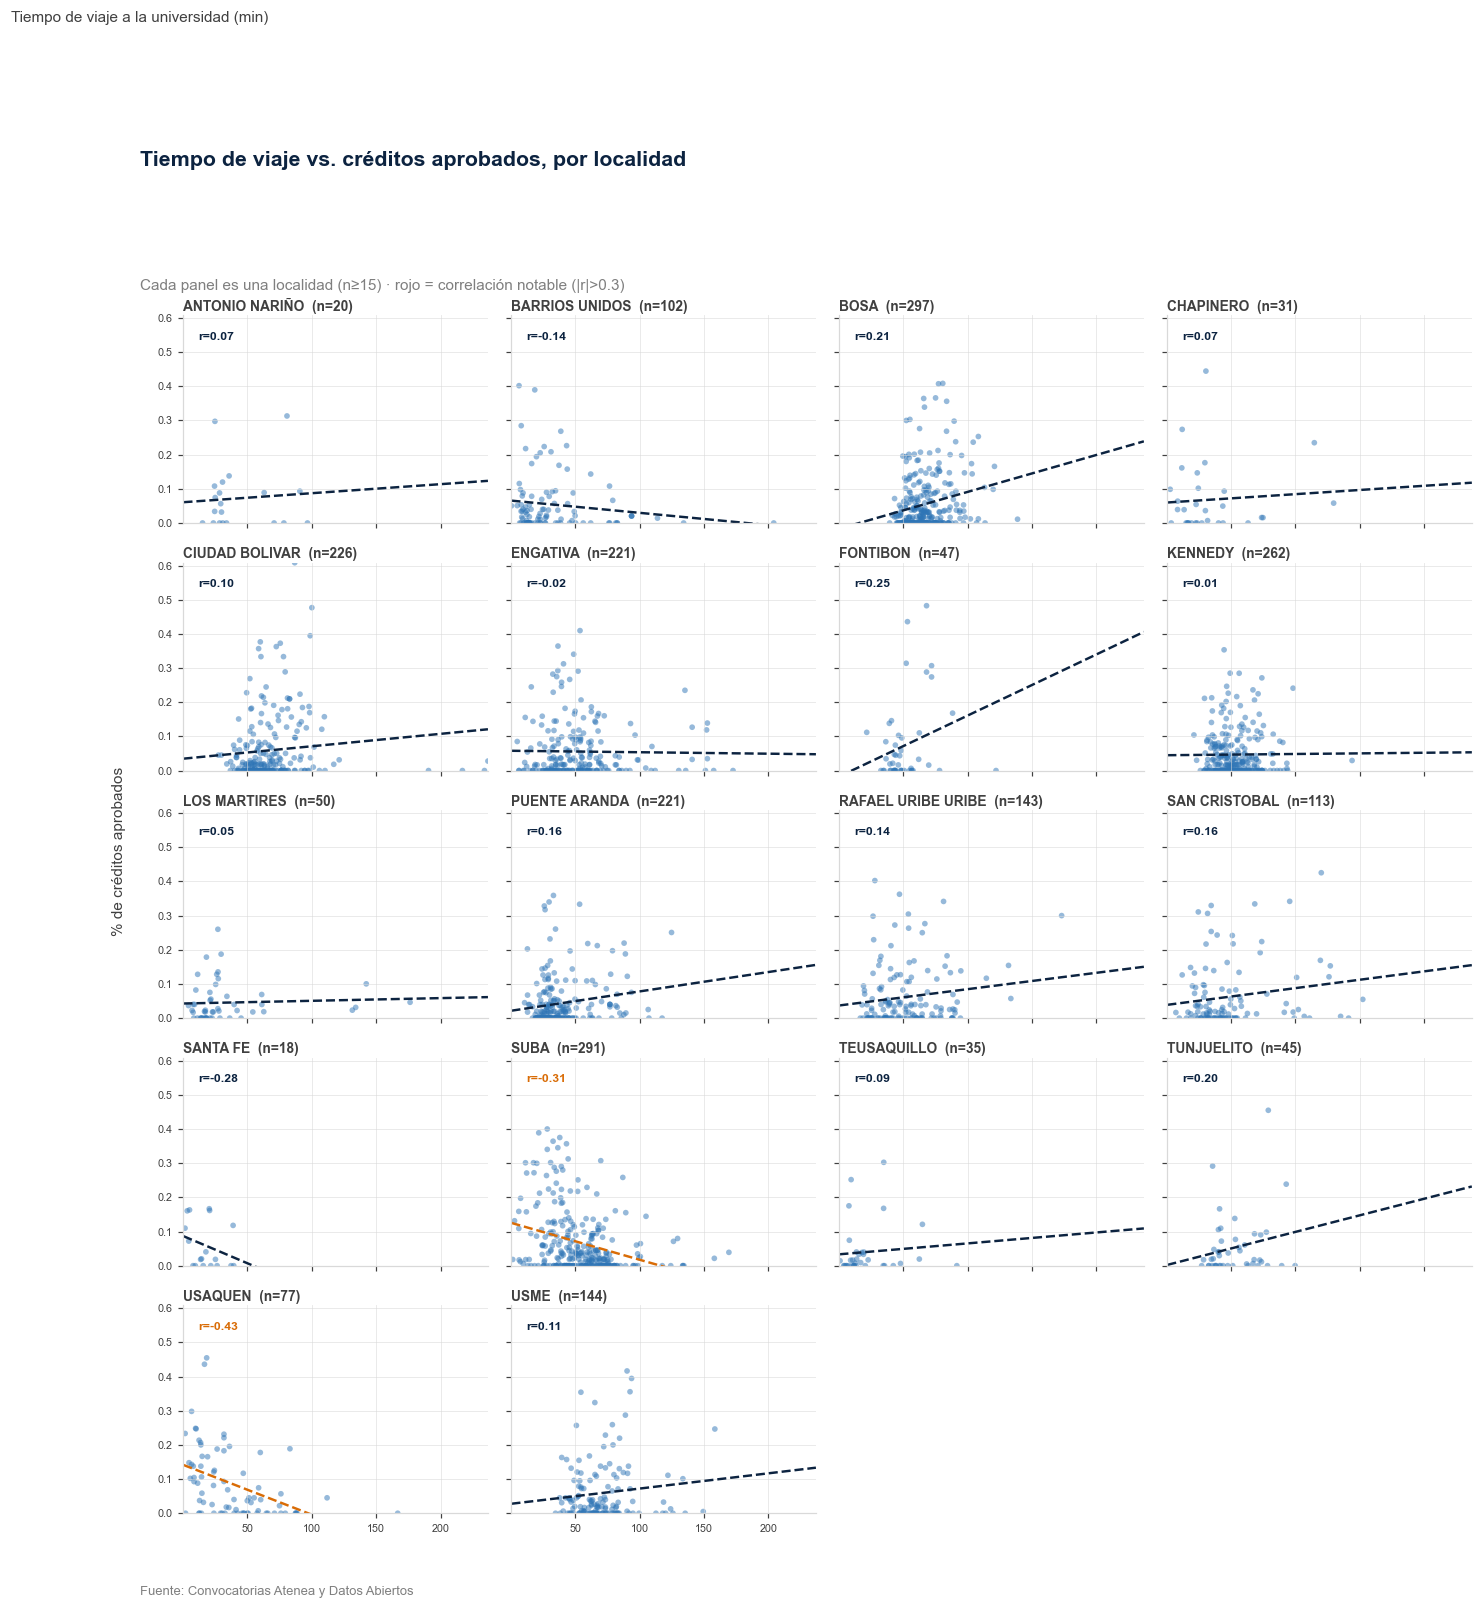

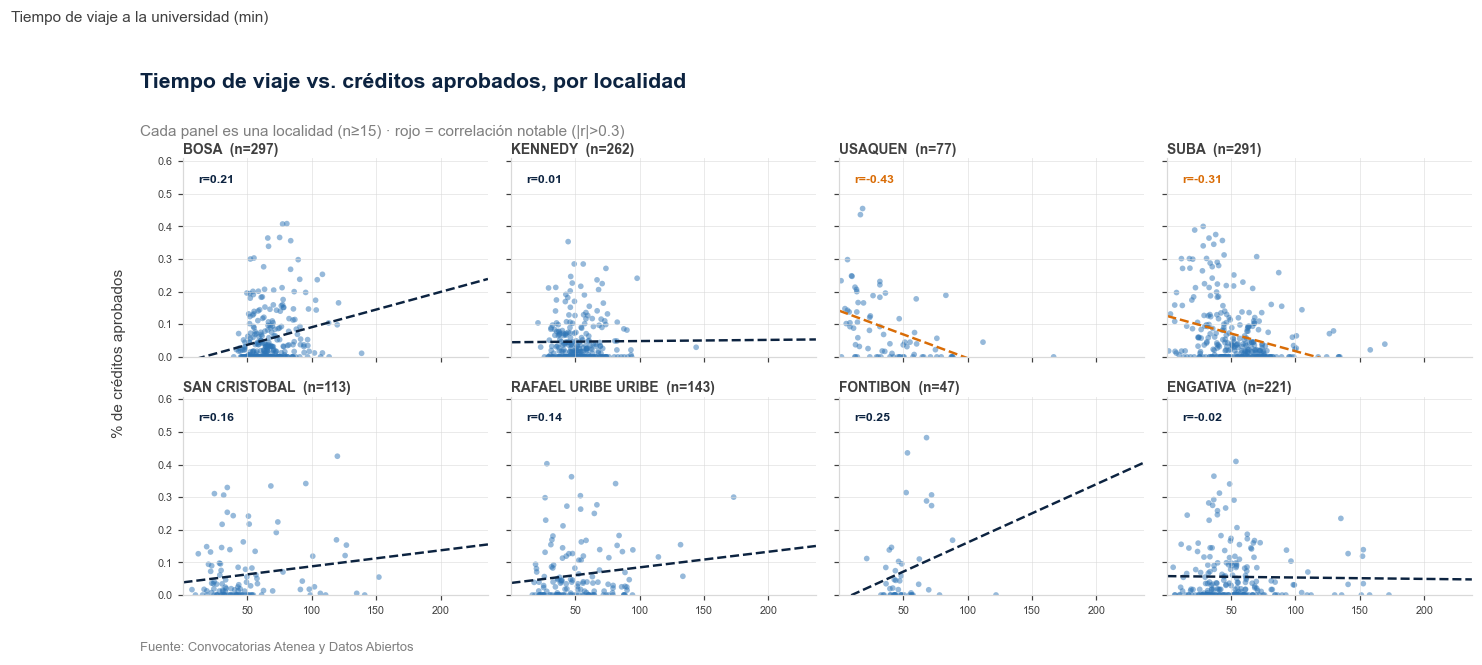

In [11]:
def graficar_dispersión_por_localidad(df, COLS, n_min=15, ncols=4,
                                        localidades_filtro=None, guardar_como=None):
    """
    Panel de dispersión (tiempo de viaje vs. créditos aprobados) por localidad.
    localidades_filtro: lista opcional de localidades a mostrar (ej. ["BOSA","SUBA"]).
                         Si es None, muestra todas las que cumplan n_min.
    """
    localidades_validas = df["LOCALIDAD"].value_counts()
    localidades_validas = localidades_validas[localidades_validas >= n_min].index.tolist()

    if localidades_filtro is not None:
        faltantes = set(localidades_filtro) - set(localidades_validas)
        if faltantes:
            print(f"Aviso: estas localidades no están disponibles (no existen o no cumplen n_min={n_min}): {faltantes}")
        localidades_validas = [l for l in localidades_filtro if l in localidades_validas]
        if not localidades_validas:
            print("Ninguna localidad del filtro cumple los requisitos. No se genera el gráfico.")
            return
    else:
        localidades_validas = sorted(localidades_validas)

    ncols_efectivo = min(ncols, len(localidades_validas))
    nrows = int(np.ceil(len(localidades_validas) / ncols_efectivo))
    fig, axes = plt.subplots(nrows, ncols_efectivo, figsize=(ncols_efectivo*3.1, nrows*2.6),
                               sharex=True, sharey=True, squeeze=False)
    axes = axes.flatten()

    xlim = (df[COLS["tiempo"]].min(), df[COLS["tiempo"]].max())
    ylim = (df[COLS["creditos_aprob"]].min(), df[COLS["creditos_aprob"]].max())

    for ax, loc in zip(axes, localidades_validas):
        sub = df[df["LOCALIDAD"] == loc]
        ax.scatter(sub[COLS["tiempo"]], sub[COLS["creditos_aprob"]], s=14, alpha=0.5,
                   color=PALETA["azul_medio"], edgecolors="none")
        if len(sub) >= 5:
            coef = np.polyfit(sub[COLS["tiempo"]], sub[COLS["creditos_aprob"]], 1)
            xs = np.linspace(*xlim, 50)
            corr = sub[[COLS["tiempo"], COLS["creditos_aprob"]]].corr().iloc[0, 1]
            color_linea = PALETA["acento"] if abs(corr) > 0.3 else PALETA["azul_oscuro"]
            ax.plot(xs, np.polyval(coef, xs), color=color_linea, linewidth=1.6, linestyle="--")
            ax.text(0.05, 0.92, f"r={corr:.2f}", transform=ax.transAxes, fontsize=8,
                     color=color_linea, va="top", fontweight="bold")
        ax.set_title(f"{loc}  (n={len(sub)})", fontsize=9, loc="left", color=PALETA["gris_oscuro"], pad=3)
        ax.set_xlim(xlim); ax.set_ylim(ylim)
        ax.tick_params(labelsize=7)

    for ax in axes[len(localidades_validas):]:
        ax.axis("off")

    fig.text(0.01, 1.08, "Tiempo de viaje a la universidad (min)", ha="center", fontsize=10, color=PALETA["gris_oscuro"])
    fig.text(-0.01, 0.5, "% de créditos aprobados", va="center", rotation="vertical", fontsize=10, color=PALETA["gris_oscuro"])
    fig.text(0.01, 0.99, "Tiempo de viaje vs. créditos aprobados, por localidad",
             fontsize=14, fontweight="bold", color=PALETA["azul_oscuro"], ha="left", va="top")
    fig.text(0.01, 0.9, f"Cada panel es una localidad (n≥{n_min}) · rojo = correlación notable (|r|>0.3)",
             fontsize=10, color=PALETA["gris"], ha="left", va="top")
    
    fuente_nota(fig, "Fuente: Convocatorias Atenea y Datos Abiertos")

    plt.tight_layout(rect=[0.01, 0.01, 1, 0.9])
    if guardar_como:
        plt.savefig(guardar_como, bbox_inches="tight", dpi=150)
    plt.show()


# --- Uso: todas las localidades ---
graficar_dispersión_por_localidad(df, COLS, guardar_como=FIGURES_DIR / "7.scatterplot_aprobacion_creditos_tiempo_localidad.png")

# --- Uso: solo las que te interesan ---
graficar_dispersión_por_localidad(df, COLS, localidades_filtro=["BOSA", "KENNEDY", "USAQUEN", "SUBA", "SAN CRISTOBAL", "RAFAEL URIBE URIBE", "FONTIBON", "ENGATIVA" ], guardar_como=FIGURES_DIR / "8.scatterplot_aprobacion_creditos_tiempo_localidad.png")

# ["USAQUEN", "SUBA", "BARRIOS UNIDOS", "ENGATIVA"]

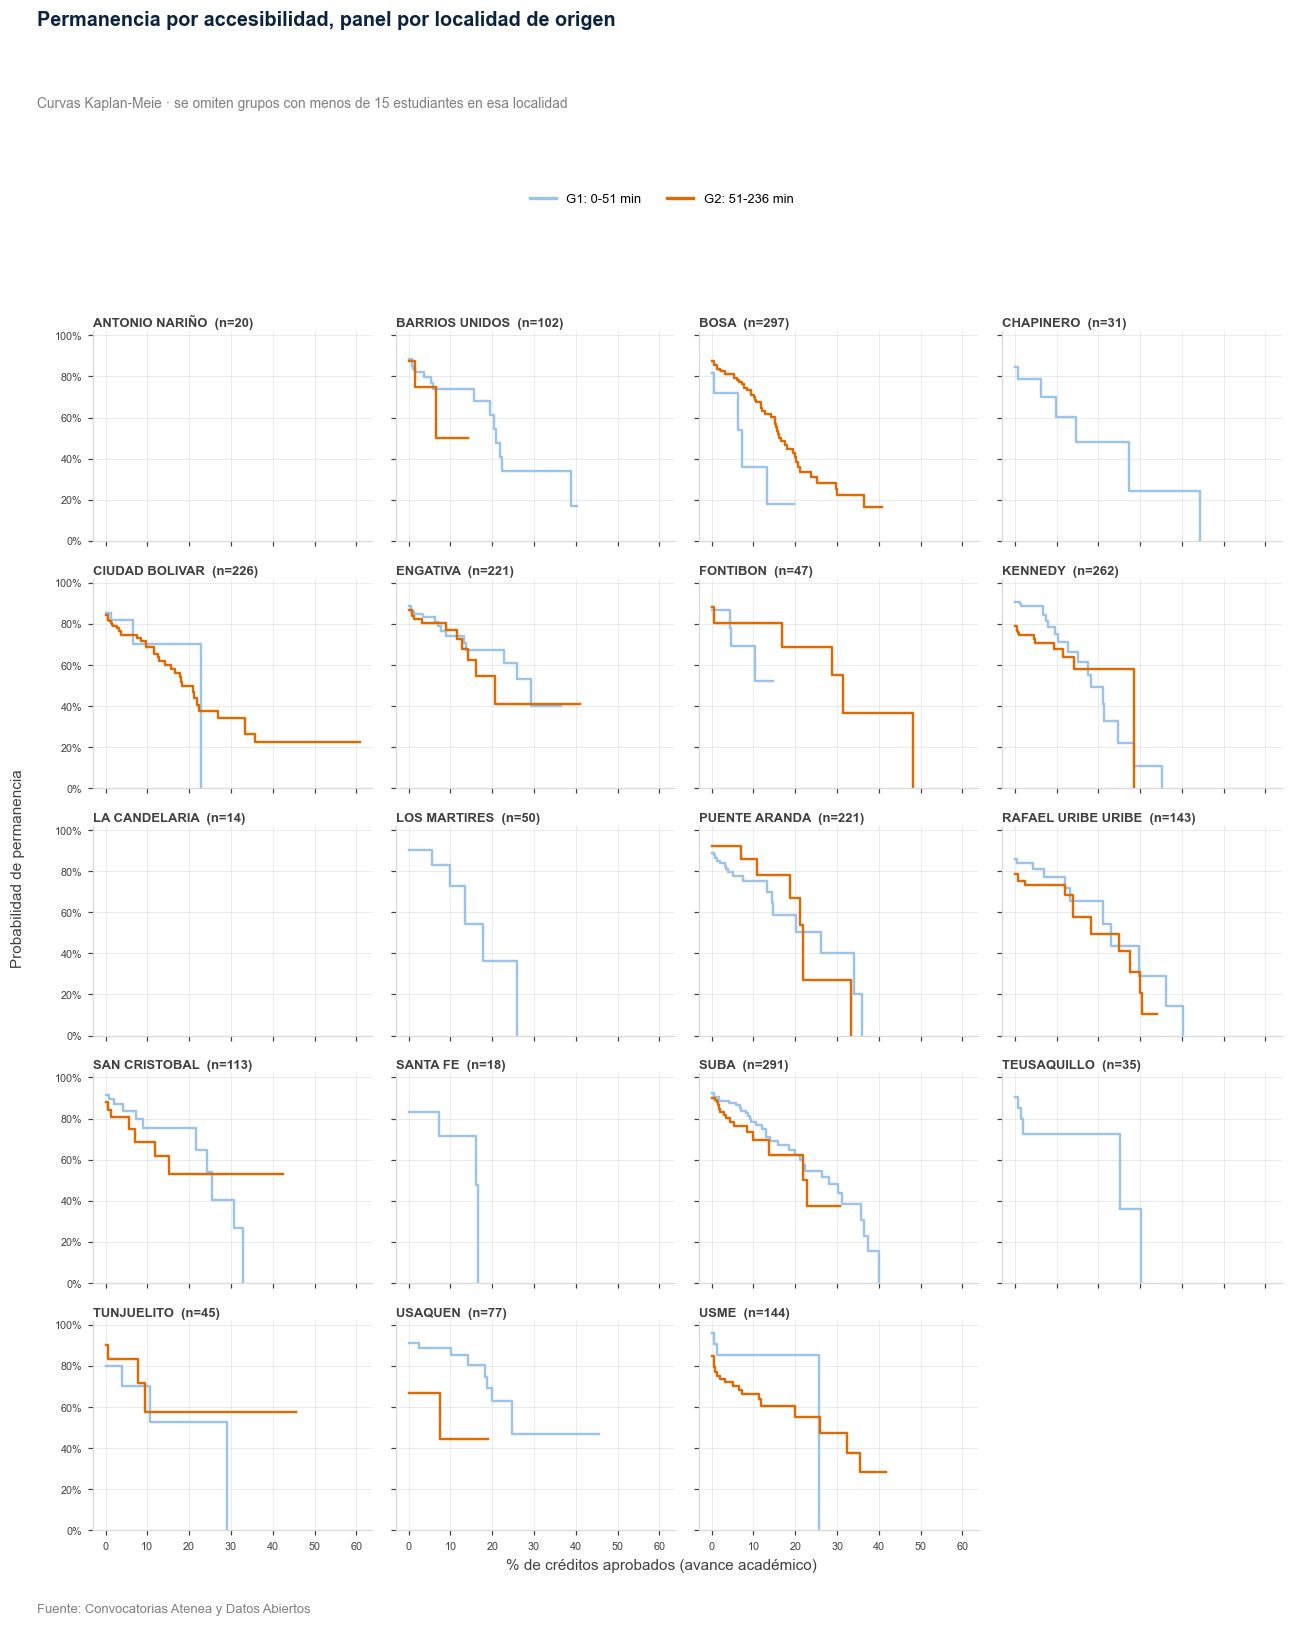

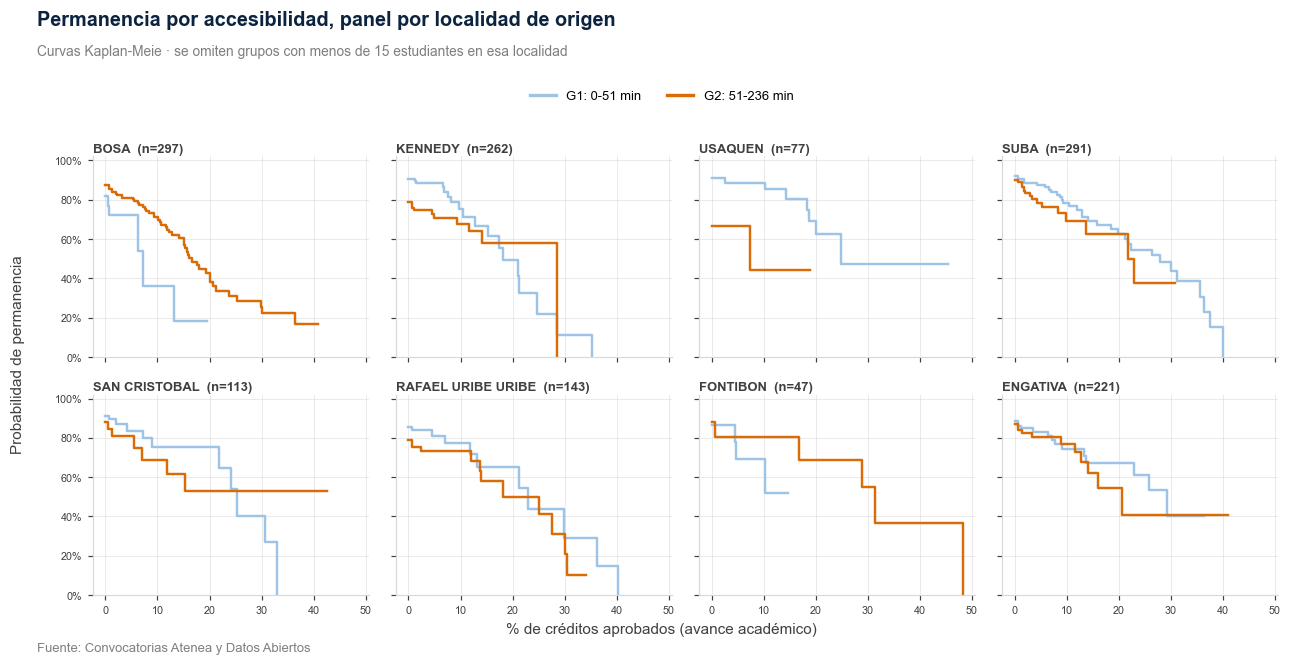

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
from lifelines import KaplanMeierFitter

def graficar_km_por_localidad(df, COLS, q=3, n_min_panel=15, ncols=4,
                                localidades_filtro=None, guardar_como=None):
    """
    Panel de curvas Kaplan-Meier (crudas, sin Cox) por localidad de origen.
    localidades_filtro: lista opcional de localidades a mostrar (ej. ["BOSA","SUBA"]).
                         Si es None, muestra todas.
    """
    df = df.copy()
    df["_grupo_q"], bins = pd.qcut(df[COLS["tiempo"]], q=q, retbins=True, duplicates="drop")
    q_efectivo = df["_grupo_q"].nunique()
    etiquetas = [f"G{i+1}: {int(bins[i])}-{int(bins[i+1])} min" for i in range(q_efectivo)]
    df["_grupo_q"] = pd.qcut(df[COLS["tiempo"]], q=q, labels=etiquetas, duplicates="drop")

    cmap = LinearSegmentedColormap.from_list("acc", [PALETA["azul_claro"], PALETA["acento"]])
    colores = {etq: cmap(i / max(q_efectivo - 1, 1)) for i, etq in enumerate(etiquetas)}

    localidades = sorted(df["LOCALIDAD"].dropna().unique())
    if localidades_filtro is not None:
        faltantes = set(localidades_filtro) - set(localidades)
        if faltantes:
            print(f"Aviso: estas localidades no existen en los datos y se ignoran: {faltantes}")
        localidades = [l for l in localidades_filtro if l in localidades]
        if not localidades:
            print("Ninguna localidad del filtro existe en los datos. No se genera el gráfico.")
            return

    ncols_efectivo = min(ncols, len(localidades))
    nrows = int(np.ceil(len(localidades) / ncols_efectivo))
    fig, axes = plt.subplots(nrows, ncols_efectivo, figsize=(ncols_efectivo*2.9, nrows*2.6),
                               sharex=True, sharey=True, squeeze=False)
    axes = axes.flatten()

    for ax, loc in zip(axes, localidades):
        sub_loc = df[df["LOCALIDAD"] == loc]
        n_total = len(sub_loc)
        for etq in etiquetas:
            sub = sub_loc[sub_loc["_grupo_q"] == etq]
            if len(sub) < n_min_panel:
                continue
            kmf = KaplanMeierFitter()
            kmf.fit(sub["_avance_pct"], sub[COLS["abandona"]])
            ax.step(kmf.survival_function_.index, kmf.survival_function_.iloc[:, 0],
                     color=colores[etq], linewidth=1.6, where="post")
        ax.set_title(f"{loc}  (n={n_total})", fontsize=8.5, loc="left", color=PALETA["gris_oscuro"], pad=3)
        ax.set_ylim(0, 1.02)
        ax.tick_params(labelsize=7)
        ax.yaxis.set_major_formatter(PercentFormatter(1.0))

    for ax in axes[len(localidades):]:
        ax.axis("off")

    fig.text(0.5, 0.01, "% de créditos aprobados (avance académico)", ha="center", fontsize=10, color=PALETA["gris_oscuro"])
    fig.text(-0.01, 0.5, "Probabilidad de permanencia", va="center", rotation="vertical", fontsize=10, color=PALETA["gris_oscuro"])
    fig.text(0.01, 1.10, "Permanencia por accesibilidad, panel por localidad de origen",
             fontsize=13, fontweight="bold", color=PALETA["azul_oscuro"], ha="left", va="top")
    fig.text(0.01, 1.04,
             f"Curvas Kaplan-Meie · se omiten grupos con menos de {n_min_panel} estudiantes en esa localidad",
             fontsize=9, color=PALETA["gris"], ha="left", va="top")
    

    # --- Leyenda compartida (una sola vez, fuera de los paneles) ---
    lineas_leyenda = [Line2D([0], [0], color=colores[etq], linewidth=2.2) for etq in etiquetas]
    fig.legend(lineas_leyenda, etiquetas, loc="upper center", bbox_to_anchor=(0.5, 0.98),
               ncol=min(q_efectivo, 5), fontsize=8.5, frameon=False,
               bbox_transform=fig.transFigure)
    fuente_nota(fig, "Fuente: Convocatorias Atenea y Datos Abiertos")

    plt.tight_layout(rect=[0.01, 0.01, 1, 0.9])
    if guardar_como:
        plt.savefig(guardar_como, bbox_inches="tight", dpi=150)
    plt.show()


# --- Uso: todas las localidades ---
graficar_km_por_localidad(df, COLS, q=2, guardar_como=FIGURES_DIR / "9.supervivencia_localidad.png")

# --- Uso: solo las localidades que te interesan ---
graficar_km_por_localidad(df, COLS, q=2, localidades_filtro=["BOSA", "KENNEDY", "USAQUEN", "SUBA", "SAN CRISTOBAL", "RAFAEL URIBE URIBE", "FONTIBON", "ENGATIVA" ],
                            guardar_como=FIGURES_DIR / "10.supervivencia_localidad_extr.png")